# Session-based SSVEP spectrograms

This notebook reproduces the legacy PCA-based SSVEP spectrogram analysis for an `ssvep-bci` session. Trials are paired from structured `stimulus_onset` and `stimulus_offset` events, resolved to configured frequencies, filtered with the legacy fourth-order 7–16 Hz band-pass, reduced to the first per-trial PCA component, and passed to SciPy's default spectrogram implementation.

The primary plots deliberately do **not** use the optional FBCCA notch or filter-bank path. Raw EEG is loaded later with an explicit nine-column `usecols` list and is never displayed.

In [1]:
from __future__ import annotations

from collections import Counter, defaultdict
from pathlib import Path
import csv
import json

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy import signal
from sklearn.decomposition import PCA

plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})


## Configuration

Set `SESSION_PATH` to another compatible session. To discover the newest compatible session below a root instead, set `SESSION_PATH = None` and set `SESSION_ROOT`.

In [2]:
SESSION_PATH: Path | None = Path(
    "ssvep-bci/sessions/20260723T165231Z_y_katkov_s_circle_3_6f0bd632"
)
SESSION_ROOT: Path | None = None

SAMPLING_RATE_HZ = 250.0
EPOCH_SECONDS = 5.0
TIMESTAMP_EDGE_TOLERANCE_SECONDS = 0.025
BANDPASS_HZ = (7.0, 16.0)
BANDPASS_ORDER = 4
PLOT_TIME_LIMIT_SECONDS = (0.0, EPOCH_SECONDS)
PLOT_FREQUENCY_LIMIT_HZ = (0.0, 20.0)

EXPECTED_TARGET_FREQUENCY_COUNTS = {
    8.25: 12,
    9.75: 12,
    12.75: 12,
    14.25: 12,
}
TIMESTAMP_COLUMN = "aligned_monotonic_timestamp"


## Load session description and events

This stage reads only session metadata, the recorded experiment protocol, device metadata, and `events.jsonl`. The EEG CSV is not touched yet.

In [3]:
REQUIRED_DESCRIPTION_FILES = (
    "manifest.json",
    "experiment-config.yaml",
    "device-profile.yaml",
    "acquisition-metadata.json",
    "events.jsonl",
)


class SessionAnalysisError(RuntimeError):
    """Actionable validation error for a session analysis input."""


def _path_candidates(path: Path) -> list[Path]:
    if path.is_absolute():
        return [path]
    search_bases = [Path.cwd(), *Path.cwd().parents]
    candidates = [base / path for base in search_bases]
    return list(dict.fromkeys(candidates))


def _is_session_directory(path: Path) -> bool:
    return path.is_dir() and all((path / name).is_file() for name in REQUIRED_DESCRIPTION_FILES)


def resolve_session_path(session_path: Path | None, session_root: Path | None) -> Path:
    if session_path is not None:
        candidates = _path_candidates(Path(session_path))
        for candidate in candidates:
            resolved = candidate.resolve()
            if _is_session_directory(resolved):
                return resolved
        checked = ", ".join(str(candidate.resolve()) for candidate in candidates)
        raise FileNotFoundError(
            f"Session directory was not found or is missing required description files. Checked: {checked}"
        )

    if session_root is None:
        raise ValueError("Set SESSION_PATH, or set SESSION_PATH=None and provide SESSION_ROOT for discovery.")

    roots = [candidate.resolve() for candidate in _path_candidates(Path(session_root))]
    existing_roots = [root for root in roots if root.is_dir()]
    if not existing_roots:
        raise FileNotFoundError(f"Session discovery root does not exist. Checked: {roots}")

    discovered = sorted(
        (child for root in existing_roots for child in root.iterdir() if _is_session_directory(child)),
        key=lambda child: child.name,
        reverse=True,
    )
    if not discovered:
        raise FileNotFoundError(
            f"No compatible session directories were found below: {existing_roots}"
        )
    return discovered[0].resolve()


def _load_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def _load_yaml(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as handle:
        return yaml.safe_load(handle)


def load_session_description(session_dir: Path) -> dict:
    events = []
    with (session_dir / "events.jsonl").open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue
            try:
                events.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise SessionAnalysisError(
                    f"Invalid JSON in events.jsonl at line {line_number}: {exc.msg}"
                ) from exc

    return {
        "manifest": _load_json(session_dir / "manifest.json"),
        "experiment": _load_yaml(session_dir / "experiment-config.yaml"),
        "device": _load_yaml(session_dir / "device-profile.yaml"),
        "acquisition": _load_json(session_dir / "acquisition-metadata.json"),
        "events": events,
    }


In [6]:
session_dir = resolve_session_path(SESSION_PATH, SESSION_ROOT)
session_description = load_session_description(session_dir)
print(f"Loaded session description and events from: {session_dir}")
print("Raw EEG has not been loaded.")


Loaded session description and events from: C:\Users\MykhailoAntropov\IdeaProjects\turiba\BCI\ssvep-bci\sessions\20260723T165231Z_y_katkov_s_circle_3_6f0bd632
Raw EEG has not been loaded.


In [7]:
def validate_recording_configuration(description: dict, expected_rate_hz: float) -> list[str]:
    acquisition = description["acquisition"]
    device = description["device"]
    channels = list(acquisition.get("channel_names") or [])
    device_channels = [channel.get("label") for channel in device.get("channels", [])]

    if len(channels) != 8:
        raise SessionAnalysisError(
            f"Expected eight configured EEG channels, but acquisition metadata lists {len(channels)}: {channels}"
        )
    if channels != device_channels:
        raise SessionAnalysisError(
            "Channel order differs between acquisition-metadata.json and device-profile.yaml: "
            f"acquisition={channels}, device={device_channels}"
        )

    configured_rates = {
        "acquisition metadata": acquisition.get("configured_sampling_rate_hz"),
        "device profile": device.get("sampling_rate_hz"),
    }
    mismatched = {
        source: value
        for source, value in configured_rates.items()
        if value is None or not np.isclose(float(value), expected_rate_hz)
    }
    if mismatched:
        raise SessionAnalysisError(
            f"Expected a {expected_rate_hz:g} Hz recording, but found incompatible values: {mismatched}"
        )
    return channels


def stimulus_frequency_map(experiment: dict) -> dict[str, float]:
    frequency_map = {}
    for stimulus in experiment.get("stimuli", []):
        stimulus_id = stimulus.get("id")
        frequency_hz = stimulus.get("frequency_hz")
        if not stimulus_id or frequency_hz is None:
            raise SessionAnalysisError(
                "Every configured stimulus must contain both 'id' and 'frequency_hz'."
            )
        frequency_map[str(stimulus_id)] = float(frequency_hz)
    if not frequency_map:
        raise SessionAnalysisError("No stimuli were found in experiment-config.yaml.")
    return frequency_map


def pair_stimulus_events(events: list[dict], frequency_map: dict[str, float]) -> list[dict]:
    buckets: dict[str, dict[str, list[dict]]] = defaultdict(lambda: defaultdict(list))
    for event in events:
        event_type = event.get("event_type")
        if event_type not in {"stimulus_onset", "stimulus_offset"}:
            continue
        pair_id = event.get("trial_id") or event.get("presentation_id")
        if not pair_id:
            raise SessionAnalysisError(
                f"A {event_type} event has no trial_id or presentation_id; sequence={event.get('sequence_number')}"
            )
        buckets[str(pair_id)][event_type].append(event)

    problems = []
    for pair_id, grouped in buckets.items():
        onset_count = len(grouped.get("stimulus_onset", []))
        offset_count = len(grouped.get("stimulus_offset", []))
        if onset_count != 1 or offset_count != 1:
            problems.append(f"{pair_id}: {onset_count} onset(s), {offset_count} offset(s)")
    if problems:
        raise SessionAnalysisError(
            "Unmatched or duplicate stimulus events. Each trial needs exactly one onset and one offset: "
            + "; ".join(problems[:12])
        )

    pairs = []
    for pair_id, grouped in buckets.items():
        onset = grouped["stimulus_onset"][0]
        offset = grouped["stimulus_offset"][0]
        onset_time = float(onset["monotonic_timestamp"])
        offset_time = float(offset["monotonic_timestamp"])
        if offset_time <= onset_time:
            raise SessionAnalysisError(
                f"Stimulus offset does not follow onset for {pair_id}: onset={onset_time}, offset={offset_time}"
            )
        if onset.get("stimulus_id") != offset.get("stimulus_id"):
            raise SessionAnalysisError(
                f"Stimulus ID mismatch for {pair_id}: onset={onset.get('stimulus_id')}, "
                f"offset={offset.get('stimulus_id')}"
            )
        stimulus_id = str(onset.get("stimulus_id"))
        if stimulus_id not in frequency_map:
            raise SessionAnalysisError(
                f"Event stimulus_id '{stimulus_id}' is absent from experiment-config.yaml."
            )
        pairs.append(
            {
                "pair_id": pair_id,
                "trial_number": onset.get("trial_number"),
                "stimulus_id": stimulus_id,
                "frequency_hz": frequency_map[stimulus_id],
                "onset_monotonic_timestamp": onset_time,
                "offset_monotonic_timestamp": offset_time,
                "event_duration_seconds": offset_time - onset_time,
            }
        )
    return sorted(pairs, key=lambda pair: pair["onset_monotonic_timestamp"])


def expected_frequency_counts(experiment: dict, frequency_map: dict[str, float]) -> dict[float, int]:
    protocol = experiment.get("protocol") or {}
    sequence = protocol.get("stimulus_sequence") or []
    repetitions = int(protocol.get("repetitions", 1))
    counts = Counter()
    for stimulus_id in sequence:
        if stimulus_id not in frequency_map:
            raise SessionAnalysisError(
                f"Protocol stimulus '{stimulus_id}' is absent from the configured stimuli."
            )
        counts[frequency_map[stimulus_id]] += repetitions
    return dict(sorted(counts.items()))


def validate_pair_counts(pairs: list[dict], expected_counts: dict[float, int]) -> dict[float, int]:
    actual_counts = dict(sorted(Counter(pair["frequency_hz"] for pair in pairs).items()))
    if actual_counts != expected_counts:
        raise SessionAnalysisError(
            f"Stimulus event counts do not match the recorded protocol: expected={expected_counts}, "
            f"actual={actual_counts}"
        )
    return actual_counts


In [8]:
channel_names = validate_recording_configuration(session_description, SAMPLING_RATE_HZ)
frequency_map = stimulus_frequency_map(session_description["experiment"])
trial_pairs = pair_stimulus_events(session_description["events"], frequency_map)
protocol_frequency_counts = expected_frequency_counts(session_description["experiment"], frequency_map)
paired_frequency_counts = validate_pair_counts(trial_pairs, protocol_frequency_counts)

if session_dir.name == "20260723T165231Z_y_katkov_s_circle_3_6f0bd632":
    if paired_frequency_counts != EXPECTED_TARGET_FREQUENCY_COUNTS:
        raise SessionAnalysisError(
            f"Target-session frequency counts are incorrect: {paired_frequency_counts}"
        )

print(f"Sampling rate: {SAMPLING_RATE_HZ:g} Hz")
print(f"Configured EEG channels ({len(channel_names)}): {', '.join(channel_names)}")
print(f"Paired stimulus events: {len(trial_pairs)}")
print(f"Paired trials per frequency: {paired_frequency_counts}")


Sampling rate: 250 Hz
Configured EEG channels (8): O1, O2, Oz, PO3, PO4, P3, P4, Pz
Paired stimulus events: 48
Paired trials per frequency: {8.25: 12, 9.75: 12, 12.75: 12, 14.25: 12}


## Load and epoch the EEG

`eeg_raw.csv` is loaded now with `pandas.read_csv(usecols=...)`, selecting only the aligned monotonic timestamp and the eight configured EEG channels. The table itself is never displayed.

Each epoch is selected by timestamp around `[onset, onset + 5 seconds)`. The small edge tolerance accommodates the acquisition timestamp alignment jitter visible in this recording; candidate samples remain timestamp-selected and excess samples are center-trimmed. Trials with too few candidates are diagnosed and excluded.

In [9]:
def load_eeg_raw(session_dir: Path, channels: list[str]) -> pd.DataFrame:
    csv_path = session_dir / "eeg_raw.csv"
    if not csv_path.is_file():
        raise FileNotFoundError(f"Raw EEG file is missing: {csv_path}")

    with csv_path.open("r", encoding="utf-8", newline="") as handle:
        header = next(csv.reader(handle), [])
    required_columns = [TIMESTAMP_COLUMN, *channels]
    missing_columns = [column for column in required_columns if column not in header]
    if missing_columns:
        raise SessionAnalysisError(
            f"eeg_raw.csv is missing required channel/timestamp columns: {missing_columns}. "
            f"Expected exactly these analysis columns: {required_columns}"
        )

    frame = pd.read_csv(csv_path, usecols=required_columns)
    for column in required_columns:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    invalid_counts = frame[required_columns].isna().sum()
    invalid_counts = invalid_counts[invalid_counts > 0].to_dict()
    if invalid_counts:
        raise SessionAnalysisError(f"Raw EEG contains missing or non-numeric analysis values: {invalid_counts}")
    if not frame[TIMESTAMP_COLUMN].is_monotonic_increasing:
        raise SessionAnalysisError(
            f"{TIMESTAMP_COLUMN} must be monotonic increasing for timestamp-based epoch extraction."
        )
    return frame


def extract_timestamp_epochs(
    raw_eeg: pd.DataFrame,
    pairs: list[dict],
    channels: list[str],
    sampling_rate_hz: float,
    epoch_seconds: float,
    edge_tolerance_seconds: float,
) -> tuple[list[dict], pd.DataFrame]:
    expected_samples = int(round(sampling_rate_hz * epoch_seconds))
    timestamps = raw_eeg[TIMESTAMP_COLUMN].to_numpy(copy=False)
    channel_values = raw_eeg[channels].to_numpy(dtype=float, copy=False)
    complete_trials = []
    diagnostics = []

    for pair in pairs:
        onset = pair["onset_monotonic_timestamp"]
        nominal_end = onset + epoch_seconds
        exact_mask = (timestamps >= onset) & (timestamps < nominal_end)
        candidate_mask = (
            (timestamps >= onset - edge_tolerance_seconds)
            & (timestamps < nominal_end + edge_tolerance_seconds)
        )
        candidate_indices = np.flatnonzero(candidate_mask)
        exact_count = int(np.count_nonzero(exact_mask))
        candidate_count = int(candidate_indices.size)
        diagnostic = {
            "pair_id": pair["pair_id"],
            "trial_number": pair["trial_number"],
            "frequency_hz": pair["frequency_hz"],
            "event_duration_seconds": pair["event_duration_seconds"],
            "exact_window_samples": exact_count,
            "candidate_samples": candidate_count,
            "expected_samples": expected_samples,
            "trimmed_from_start": 0,
            "trimmed_from_end": 0,
            "extracted_samples": 0,
            "status": "incomplete",
            "reason": "",
        }

        if pair["offset_monotonic_timestamp"] < nominal_end - edge_tolerance_seconds:
            diagnostic["reason"] = (
                f"stimulus offset occurs before the requested {epoch_seconds:g}-second epoch ends"
            )
            diagnostics.append(diagnostic)
            continue
        if candidate_count < expected_samples:
            diagnostic["reason"] = (
                f"only {candidate_count} timestamp-selected samples are available; need {expected_samples}"
            )
            diagnostics.append(diagnostic)
            continue

        excess = candidate_count - expected_samples
        trim_start = excess // 2
        trim_end = excess - trim_start
        selected_indices = candidate_indices[trim_start : candidate_count - trim_end]
        epoch = np.array(channel_values[selected_indices], dtype=float, copy=True)
        if epoch.shape != (expected_samples, len(channels)):
            diagnostic["reason"] = f"unexpected extracted shape {epoch.shape}"
            diagnostics.append(diagnostic)
            continue

        diagnostic.update(
            {
                "trimmed_from_start": trim_start,
                "trimmed_from_end": trim_end,
                "extracted_samples": int(epoch.shape[0]),
                "status": "complete",
                "reason": "",
            }
        )
        diagnostics.append(diagnostic)
        complete_trials.append({**pair, "epoch": epoch})

    return complete_trials, pd.DataFrame(diagnostics)


def validate_complete_trial_counts(
    complete_trials: list[dict],
    diagnostics: pd.DataFrame,
    expected_counts: dict[float, int],
) -> dict[float, int]:
    incomplete = diagnostics.loc[diagnostics["status"] != "complete"]
    if not incomplete.empty:
        details = "; ".join(
            f"{row.pair_id} ({row.frequency_hz:g} Hz): {row.reason}"
            for row in incomplete.itertuples()
        )
        raise SessionAnalysisError(f"Incomplete trial epoch(s) were excluded: {details}")

    actual_counts = dict(sorted(Counter(trial["frequency_hz"] for trial in complete_trials).items()))
    if actual_counts != expected_counts:
        raise SessionAnalysisError(
            f"Complete epoch counts do not match the protocol: expected={expected_counts}, actual={actual_counts}"
        )
    return actual_counts


In [10]:
raw_eeg = load_eeg_raw(session_dir, channel_names)
print(
    f"Loaded {len(raw_eeg):,} EEG samples using {1 + len(channel_names)} selected columns; "
    "raw values are intentionally not displayed."
)


Loaded 97,006 EEG samples using 9 selected columns; raw values are intentionally not displayed.


In [11]:
complete_trials, trial_diagnostics = extract_timestamp_epochs(
    raw_eeg,
    trial_pairs,
    channel_names,
    SAMPLING_RATE_HZ,
    EPOCH_SECONDS,
    TIMESTAMP_EDGE_TOLERANCE_SECONDS,
)
complete_frequency_counts = validate_complete_trial_counts(
    complete_trials, trial_diagnostics, protocol_frequency_counts
)

exact_count_distribution = dict(
    sorted(Counter(trial_diagnostics["exact_window_samples"].astype(int)).items())
)
candidate_count_distribution = dict(
    sorted(Counter(trial_diagnostics["candidate_samples"].astype(int)).items())
)
print(f"Exact five-second timestamp-window sample counts: {exact_count_distribution}")
print(f"Edge-tolerant candidate sample counts: {candidate_count_distribution}")
print(f"Complete 1,250-sample epochs: {len(complete_trials)}")
print(f"Complete trials per frequency: {complete_frequency_counts}")


Exact five-second timestamp-window sample counts: {1247: 17, 1248: 24, 1262: 2, 1263: 5}
Edge-tolerant candidate sample counts: {1262: 18, 1263: 28, 1274: 1, 1278: 1}
Complete 1,250-sample epochs: 48
Complete trials per frequency: {8.25: 12, 9.75: 12, 12.75: 12, 14.25: 12}


## Legacy preprocessing, per-trial PCA, and spectrograms

Filtering is applied independently to every EEG channel with a fourth-order zero-phase Butterworth 7–16 Hz band-pass. PCA is fitted separately for each trial across the eight filtered channels. As in the legacy notebook, only the first of three PCA components is passed to `scipy.signal.spectrogram`, with SciPy's default windowing parameters.

In [12]:
def preprocess_trials(
    trials: list[dict],
    sampling_rate_hz: float,
    bandpass_hz: tuple[float, float],
    filter_order: int,
) -> list[dict]:
    b, a = signal.butter(filter_order, bandpass_hz, btype="bandpass", fs=sampling_rate_hz)
    processed = []
    for trial in trials:
        epoch = trial["epoch"]
        filtered = np.empty_like(epoch)
        for channel_index in range(epoch.shape[1]):
            filtered[:, channel_index] = signal.filtfilt(b, a, epoch[:, channel_index])

        principal_components = PCA(n_components=3).fit_transform(filtered)
        first_component = principal_components[:, 0]
        frequencies, times, power = signal.spectrogram(first_component, fs=sampling_rate_hz)
        processed.append(
            {
                "pair_id": trial["pair_id"],
                "trial_number": trial["trial_number"],
                "stimulus_id": trial["stimulus_id"],
                "frequency_hz": trial["frequency_hz"],
                "principal_component_1": first_component,
                "spectrogram_frequencies": frequencies,
                "spectrogram_times": times,
                "spectrogram_power": power,
            }
        )
    return processed


processed_trials = preprocess_trials(
    complete_trials,
    SAMPLING_RATE_HZ,
    BANDPASS_HZ,
    BANDPASS_ORDER,
)

# Remove the full raw table and unfiltered epoch copies before plotting to avoid accidental display.
del raw_eeg
del complete_trials
print(f"Computed filtered PCA spectrograms for {len(processed_trials)} trials.")


Computed filtered PCA spectrograms for 48 trials.


## Compact session summary

In [13]:
manifest = session_description["manifest"]
count_text = ", ".join(
    f"{frequency:g} Hz: {count}" for frequency, count in complete_frequency_counts.items()
)
summary = pd.DataFrame(
    [
        ("Session", session_dir.name),
        ("Participant", manifest.get("participant_id")),
        ("Session status", manifest.get("status")),
        ("Sampling rate", f"{SAMPLING_RATE_HZ:g} Hz"),
        ("EEG channels", f"{len(channel_names)} ({', '.join(channel_names)})"),
        ("Paired onset/offset trials", len(trial_pairs)),
        ("Epoch shape", f"1,250 samples × {len(channel_names)} channels"),
        ("Complete trials", len(processed_trials)),
        ("Trials per frequency", count_text),
        ("Preprocessing", "4th-order zero-phase Butterworth, 7–16 Hz"),
        ("Spatial reduction", "Per-trial PCA, first component"),
    ],
    columns=["Metric", "Value"],
)
display(summary)


,Metric,Value
0,Session,20260723T165231Z_y_katkov_s_circle_3_6f0bd632
1,Participant,y_katkov
2,Session status,complete
3,Sampling rate,250 Hz
4,EEG channels,"8 (O1, O2, Oz, PO3, PO4, P3, P4, Pz)"
5,Paired onset/offset trials,48
6,Epoch shape,"1,250 samples × 8 channels"
7,Complete trials,48
8,Trials per frequency,"8.25 Hz: 12, 9.75 Hz: 12, 12.75 Hz: 12, 14.25 ..."
9,Preprocessing,"4th-order zero-phase Butterworth, 7–16 Hz"


## Frequency-grouped trial grids

One 3×4 grid is rendered for each configured frequency. The dashed line marks the stimulus frequency.

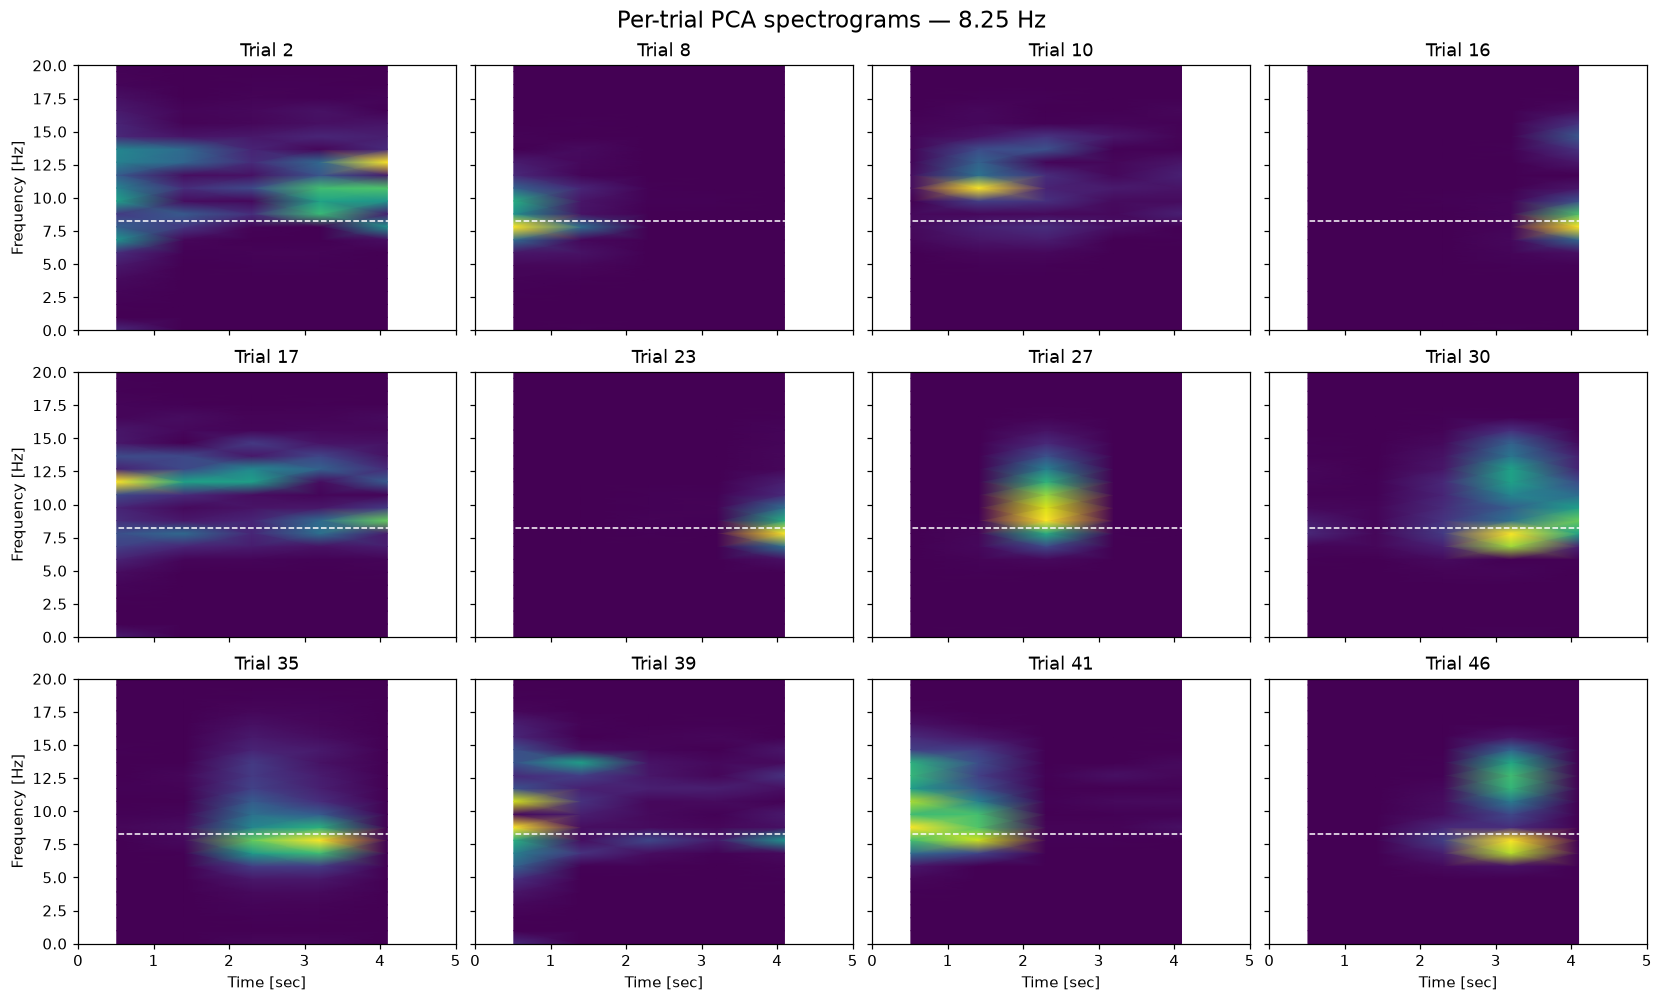

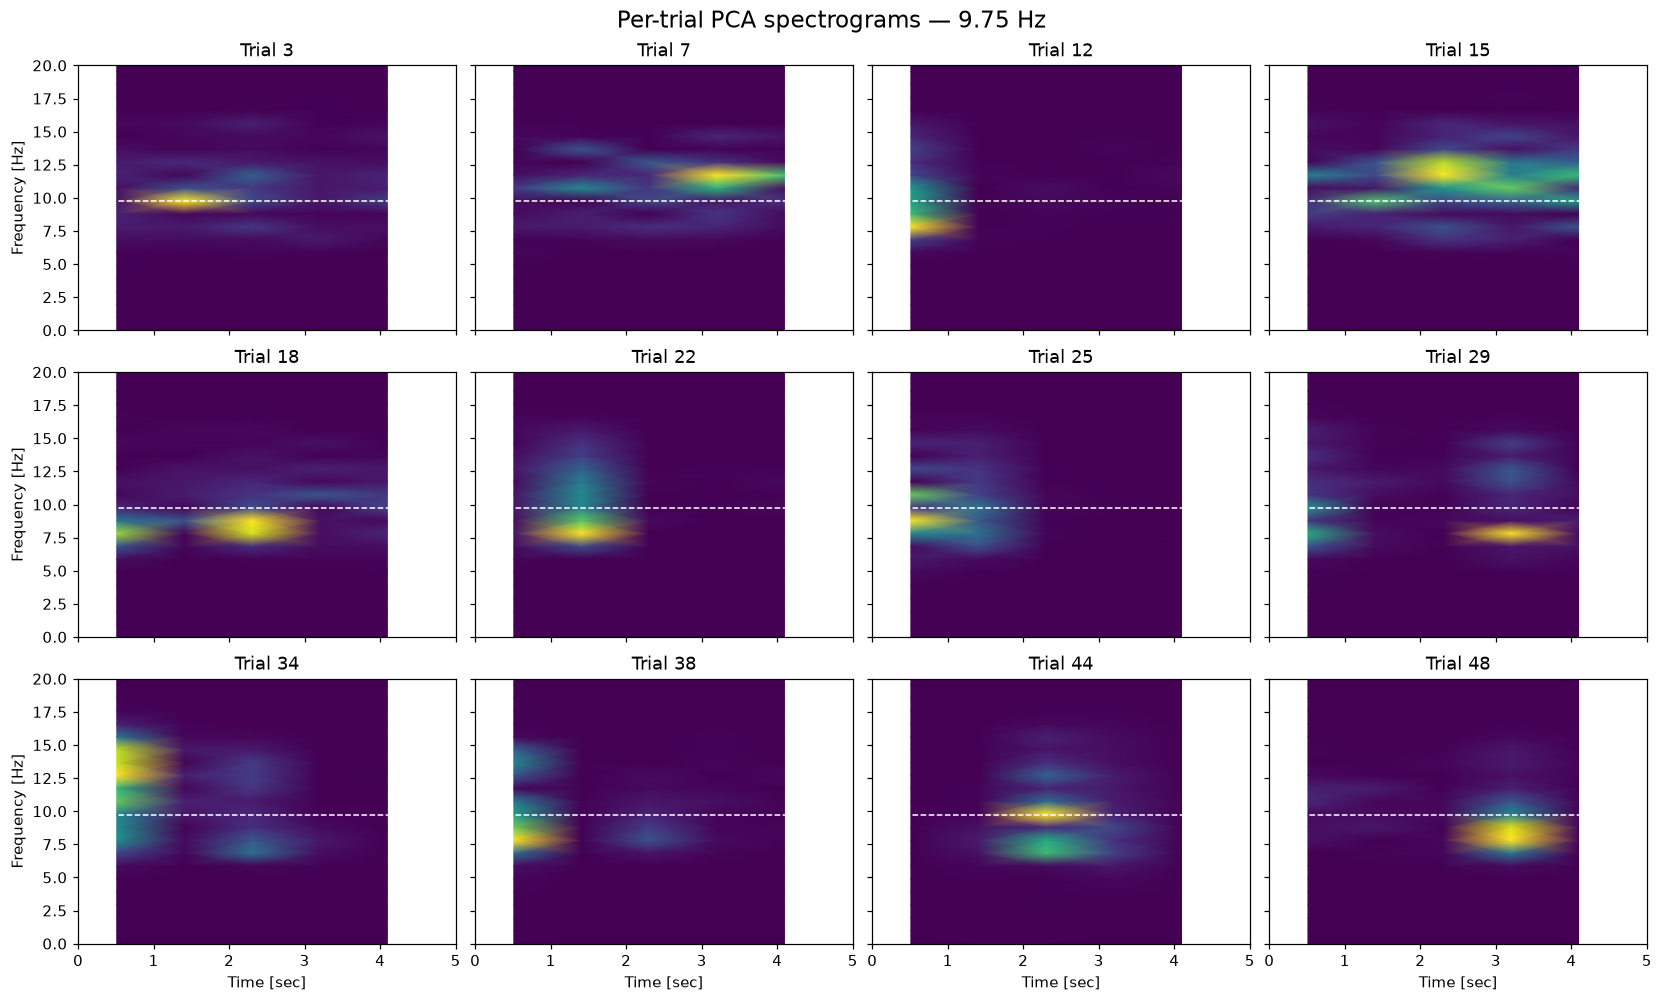

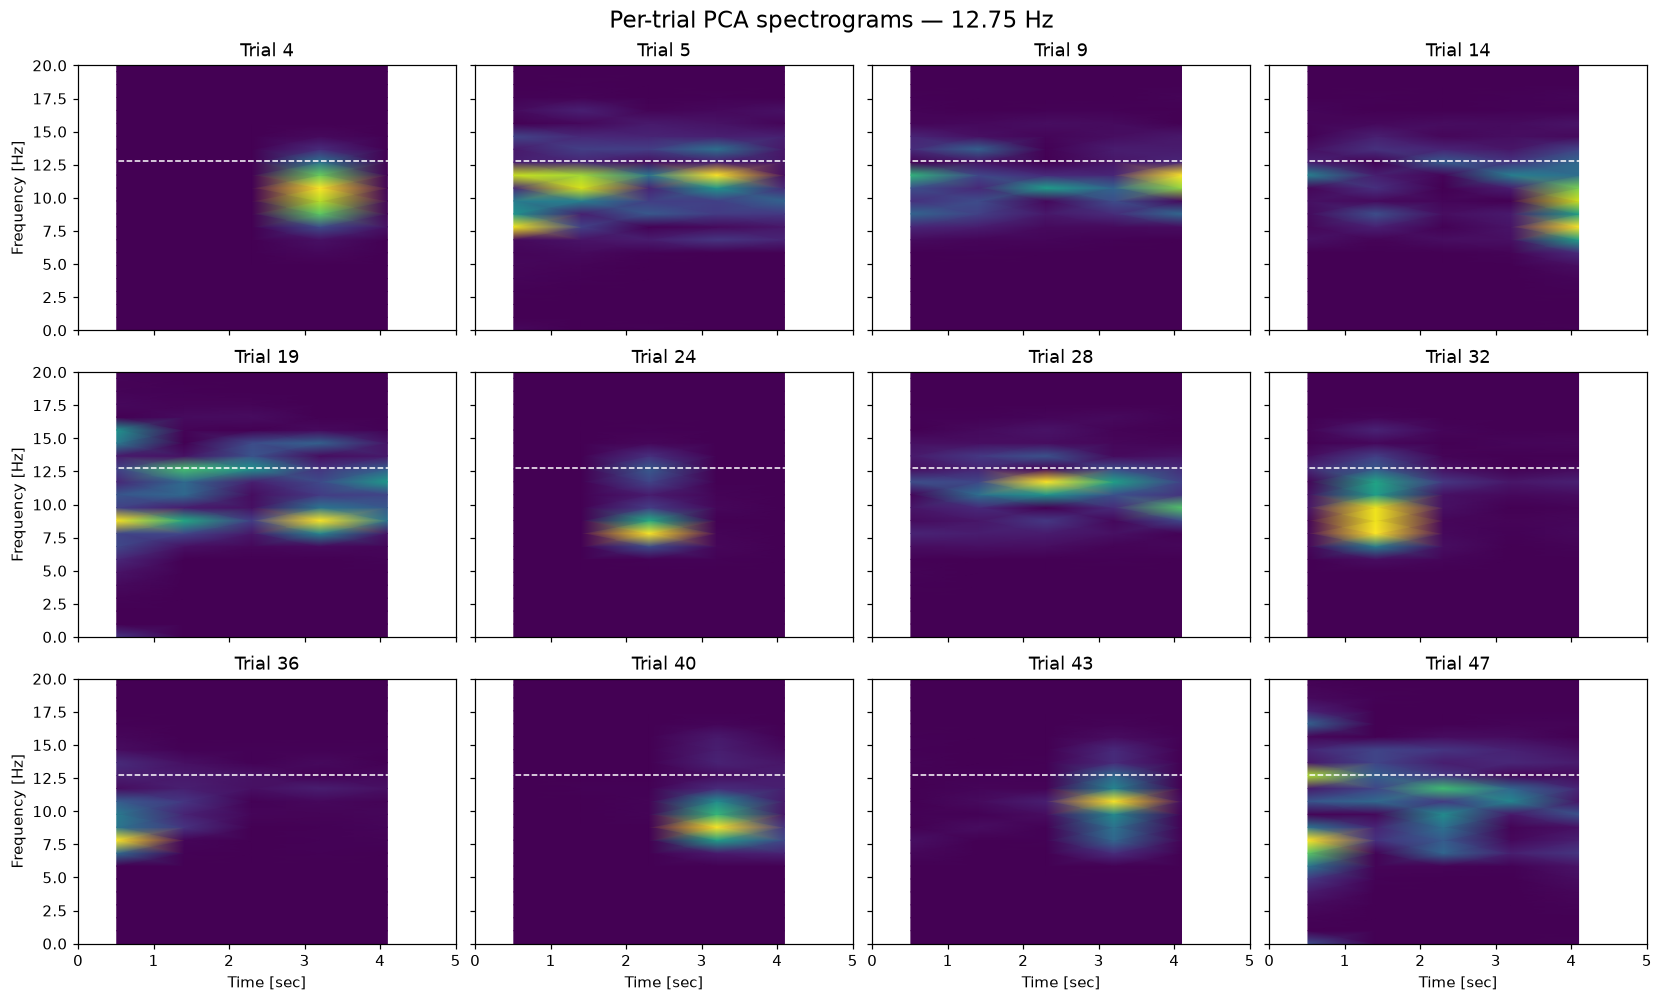

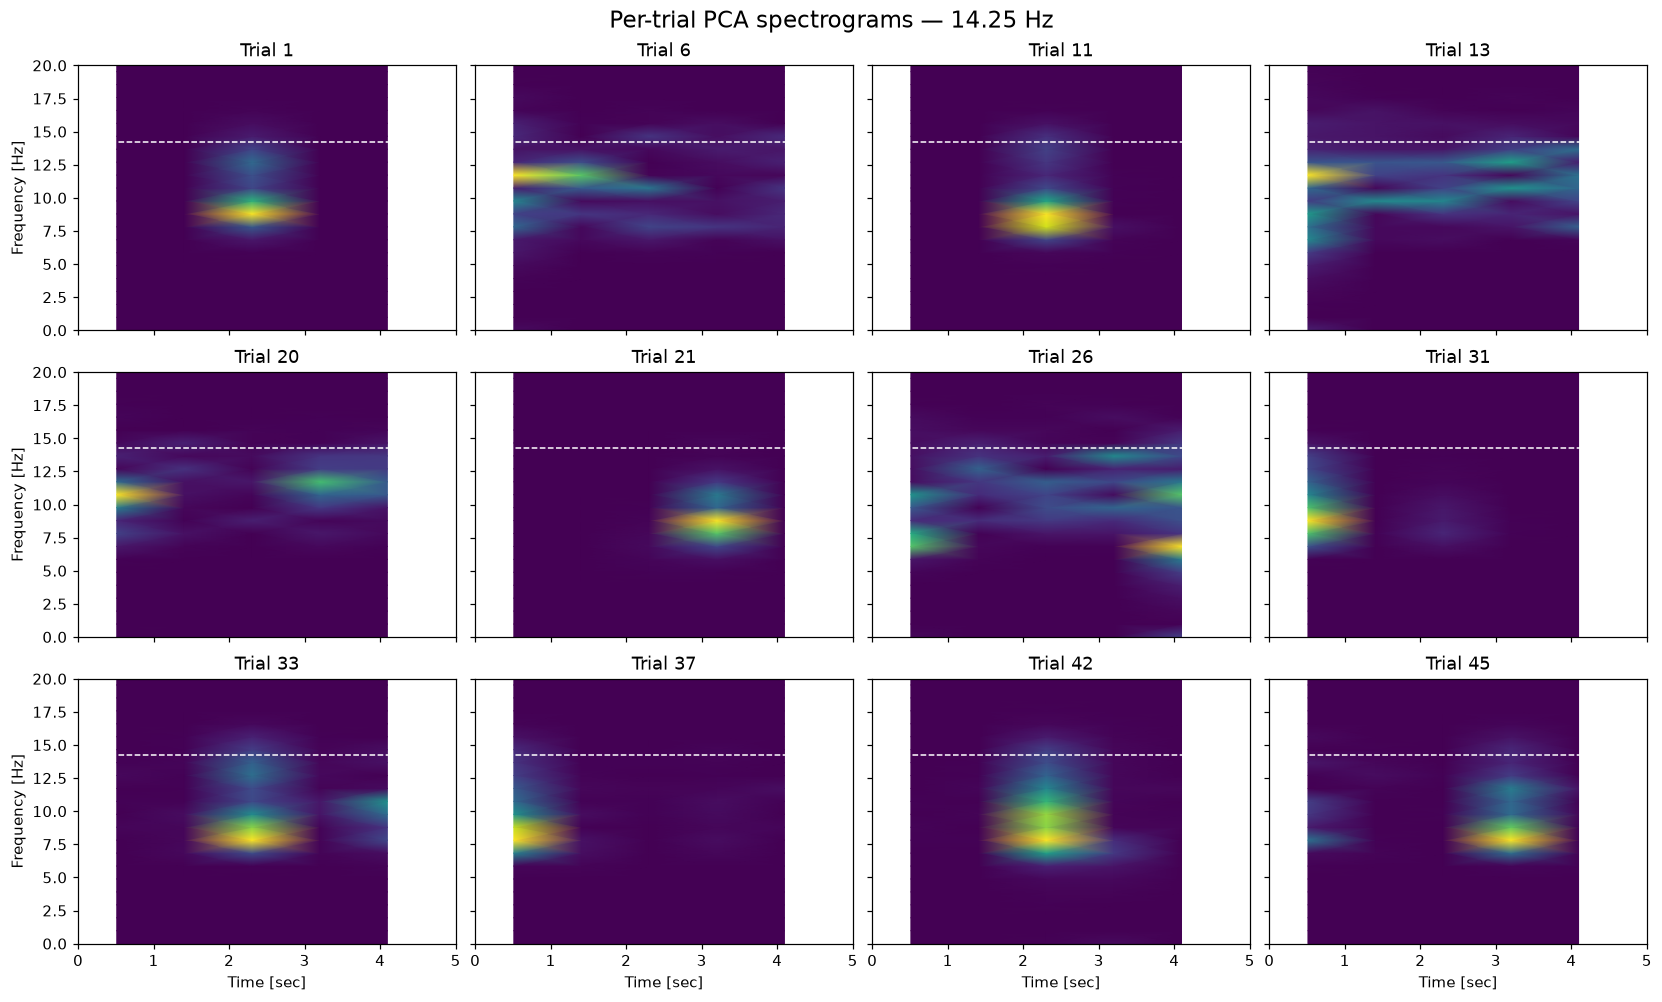

Rendered 4 frequency-grouped trial-grid figures.


In [14]:
def trials_for_frequency(processed: list[dict], frequency_hz: float) -> list[dict]:
    return sorted(
        (trial for trial in processed if np.isclose(trial["frequency_hz"], frequency_hz)),
        key=lambda trial: trial["trial_number"] if trial["trial_number"] is not None else 0,
    )


def plot_trial_grid(frequency_hz: float, trials: list[dict]) -> plt.Figure:
    fig, axes = plt.subplots(3, 4, figsize=(15, 9), sharex=True, sharey=True, constrained_layout=True)
    for plot_index, (axis, trial) in enumerate(zip(axes.flat, trials), start=1):
        axis.pcolormesh(
            trial["spectrogram_times"],
            trial["spectrogram_frequencies"],
            trial["spectrogram_power"],
            shading="gouraud",
        )
        axis.axhline(frequency_hz, color="white", linestyle="--", linewidth=1.0)
        axis.set_xlim(*PLOT_TIME_LIMIT_SECONDS)
        axis.set_ylim(*PLOT_FREQUENCY_LIMIT_HZ)
        label = trial["trial_number"] if trial["trial_number"] is not None else plot_index
        axis.set_title(f"Trial {label}")
        if (plot_index - 1) // 4 == 2:
            axis.set_xlabel("Time [sec]")
        if (plot_index - 1) % 4 == 0:
            axis.set_ylabel("Frequency [Hz]")
    for axis in axes.flat[len(trials) :]:
        axis.set_visible(False)
    fig.suptitle(f"Per-trial PCA spectrograms — {frequency_hz:g} Hz", fontsize=15)
    plt.show()
    return fig


trial_grid_figures = []
for frequency_hz in sorted(complete_frequency_counts):
    grouped_trials = trials_for_frequency(processed_trials, frequency_hz)
    trial_grid_figures.append(plot_trial_grid(frequency_hz, grouped_trials))
print(f"Rendered {len(trial_grid_figures)} frequency-grouped trial-grid figures.")


## Frequency-level summary spectrograms

Each summary is the element-wise mean of the 12 per-trial spectrogram power matrices for that frequency.

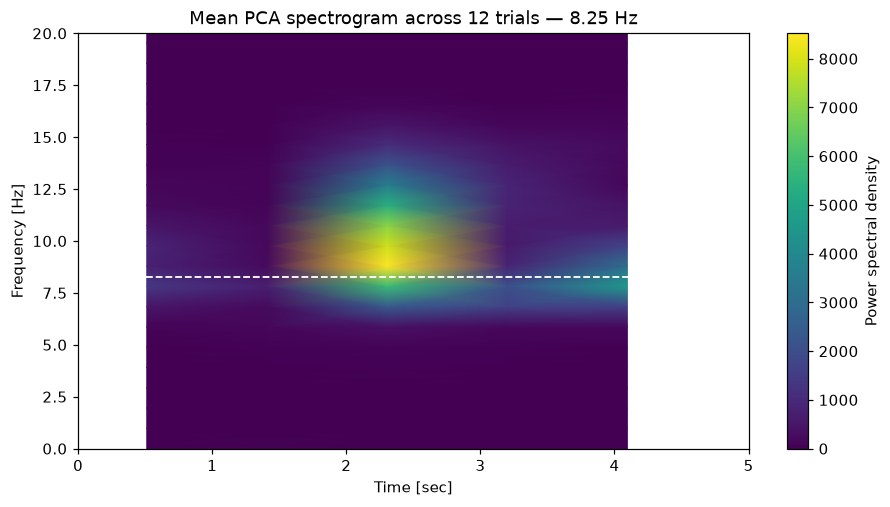

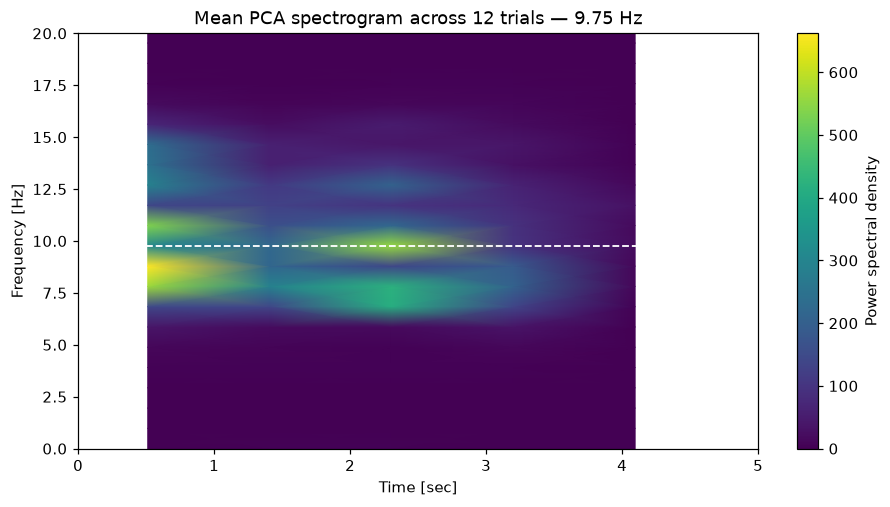

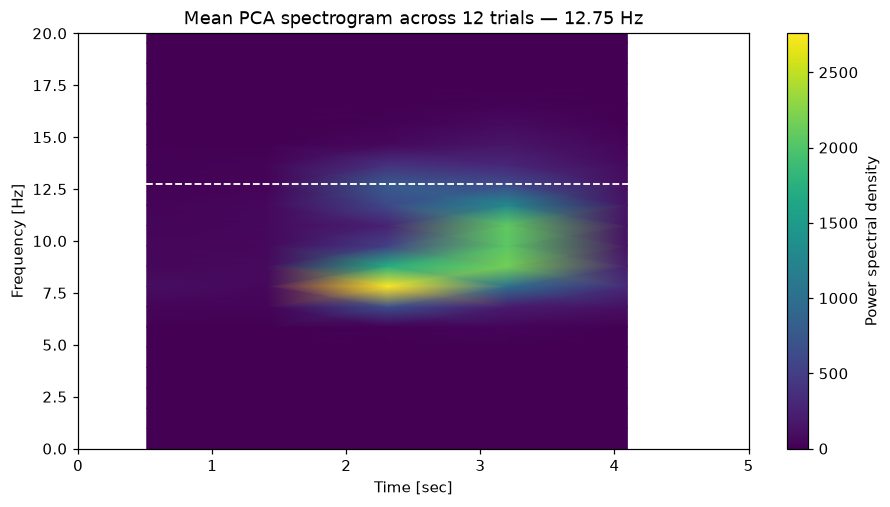

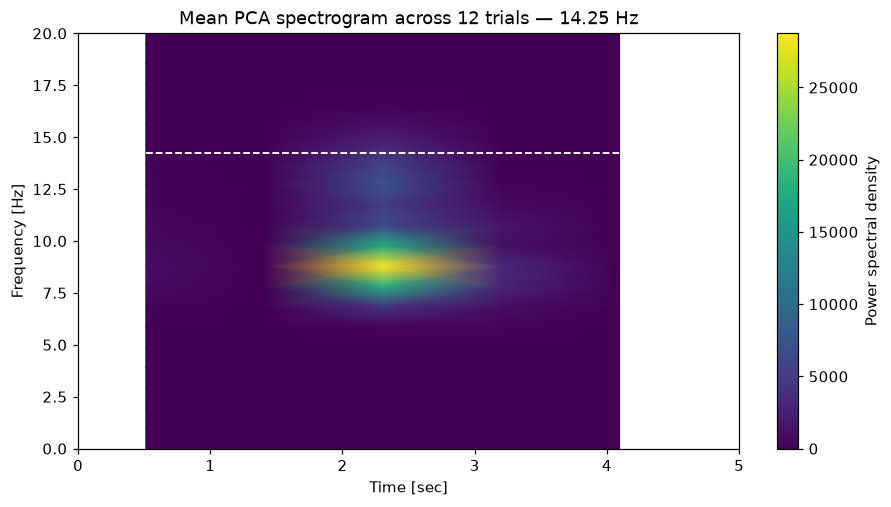

Rendered 4 frequency-level summary figures.


In [15]:
def plot_frequency_summary(frequency_hz: float, trials: list[dict]) -> plt.Figure:
    mean_power = np.mean(
        np.stack([trial["spectrogram_power"] for trial in trials], axis=0),
        axis=0,
    )
    frequencies = trials[0]["spectrogram_frequencies"]
    times = trials[0]["spectrogram_times"]
    fig, axis = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    mesh = axis.pcolormesh(times, frequencies, mean_power, shading="gouraud")
    axis.axhline(frequency_hz, color="white", linestyle="--", linewidth=1.2)
    axis.set_xlim(*PLOT_TIME_LIMIT_SECONDS)
    axis.set_ylim(*PLOT_FREQUENCY_LIMIT_HZ)
    axis.set_xlabel("Time [sec]")
    axis.set_ylabel("Frequency [Hz]")
    axis.set_title(f"Mean PCA spectrogram across {len(trials)} trials — {frequency_hz:g} Hz")
    fig.colorbar(mesh, ax=axis, label="Power spectral density")
    plt.show()
    return fig


summary_figures = []
for frequency_hz in sorted(complete_frequency_counts):
    grouped_trials = trials_for_frequency(processed_trials, frequency_hz)
    summary_figures.append(plot_frequency_summary(frequency_hz, grouped_trials))
print(f"Rendered {len(summary_figures)} frequency-level summary figures.")


## Verification

In [16]:
assert np.isclose(SAMPLING_RATE_HZ, 250.0)
assert channel_names == ["O1", "O2", "Oz", "PO3", "PO4", "P3", "P4", "Pz"]
assert len(trial_pairs) == 48
assert paired_frequency_counts == EXPECTED_TARGET_FREQUENCY_COUNTS
assert complete_frequency_counts == EXPECTED_TARGET_FREQUENCY_COUNTS
assert set(trial_diagnostics["extracted_samples"]) == {1250}
assert len(trial_grid_figures) == 4
assert len(summary_figures) == 4
assert all(len(trials_for_frequency(processed_trials, frequency)) == 12 for frequency in complete_frequency_counts)
print(
    "Verification passed: 250 Hz, eight channels, 48 paired and complete trials, "
    "12 trials at each frequency, 1,250 samples per epoch, four trial grids, and four summaries."
)
print("Trial boundaries came only from monotonic event/EEG timestamps; CSV row positions and marker values were not used.")


Verification passed: 250 Hz, eight channels, 48 paired and complete trials, 12 trials at each frequency, 1,250 samples per epoch, four trial grids, and four summaries.
Trial boundaries came only from monotonic event/EEG timestamps; CSV row positions and marker values were not used.
